In [1]:
pip install pandas numpy nltk matplotlib seaborn wordcloud scikit-learn

In [2]:
import pandas as pd

# Sample customer feedback
data = {
    "Customer_ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],

    "Feedback": [
        "The product quality is excellent and I really love it.",
        "The price is too high compared to similar products.",
        "The packaging was damaged when I received the product.",
        "Very easy to use and the design is beautiful.",
        "The product stopped working after one week.",
        "Good product but the packaging needs improvement.",
        "I am happy with the quality and reasonable price.",
        "The instructions are confusing and difficult to understand.",
        "Excellent product, but delivery was very slow.",
        "The product is expensive but the quality is good."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display data
print("Product Feedback Data:")
print(df)

# Save dataset
df.to_csv("product_feedback.csv", index=False)

print("\nDataset saved successfully!")

Product Feedback Data:
   Customer_ID                                           Feedback
0            1  The product quality is excellent and I really ...
1            2  The price is too high compared to similar prod...
2            3  The packaging was damaged when I received the ...
3            4      Very easy to use and the design is beautiful.
4            5        The product stopped working after one week.
5            6  Good product but the packaging needs improvement.
6            7  I am happy with the quality and reasonable price.
7            8  The instructions are confusing and difficult t...
8            9     Excellent product, but delivery was very slow.
9           10  The product is expensive but the quality is good.

Dataset saved successfully!


In [3]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
import pandas as pd
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load data
df = pd.read_csv("product_feedback.csv")

# Stopwords
stop_words = set(stopwords.words("english"))

# Lemmatizer
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Split into words
    words = text.split()

    # Remove stopwords and perform lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words
    return " ".join(words)


# Apply preprocessing
df["Cleaned_Feedback"] = df["Feedback"].apply(preprocess_text)

# Display result
print(df[["Feedback", "Cleaned_Feedback"]])

# Save preprocessed data
df.to_csv("preprocessed_feedback.csv", index=False)

                                            Feedback  \
0  The product quality is excellent and I really ...   
1  The price is too high compared to similar prod...   
2  The packaging was damaged when I received the ...   
3      Very easy to use and the design is beautiful.   
4        The product stopped working after one week.   
5  Good product but the packaging needs improvement.   
6  I am happy with the quality and reasonable price.   
7  The instructions are confusing and difficult t...   
8     Excellent product, but delivery was very slow.   
9  The product is expensive but the quality is good.   

                             Cleaned_Feedback  
0       product quality excellent really love  
1         price high compared similar product  
2          packaging damaged received product  
3                   easy use design beautiful  
4            product stopped working one week  
5     good product packaging need improvement  
6              happy quality reasonable price  

In [5]:
import nltk

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [6]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer

# Load preprocessed data
df = pd.read_csv("preprocessed_feedback.csv")

# Create sentiment analyzer
sia = SentimentIntensityAnalyzer()


def get_sentiment(text):

    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"


# Apply sentiment analysis
df["Sentiment"] = df["Feedback"].apply(get_sentiment)

# Get sentiment score
df["Sentiment_Score"] = df["Feedback"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

# Display results
print(df[
    [
        "Feedback",
        "Sentiment",
        "Sentiment_Score"
    ]
])

# Save results
df.to_csv("sentiment_analysis.csv", index=False)

                                            Feedback Sentiment  \
0  The product quality is excellent and I really ...  Positive   
1  The price is too high compared to similar prod...   Neutral   
2  The packaging was damaged when I received the ...  Negative   
3      Very easy to use and the design is beautiful.  Positive   
4        The product stopped working after one week.  Negative   
5  Good product but the packaging needs improvement.  Positive   
6  I am happy with the quality and reasonable price.  Positive   
7  The instructions are confusing and difficult t...  Negative   
8     Excellent product, but delivery was very slow.  Positive   
9  The product is expensive but the quality is good.  Positive   

   Sentiment_Score  
0           0.8479  
1           0.0000  
2          -0.4404  
3           0.7960  
4          -0.2263  
5           0.7140  
6           0.5719  
7          -0.5267  
8           0.3291  
9           0.5927  


In [7]:
print("\nSentiment Distribution:")

print(df["Sentiment"].value_counts())


Sentiment Distribution:
Sentiment
Positive    6
Negative    3
Neutral     1
Name: count, dtype: int64


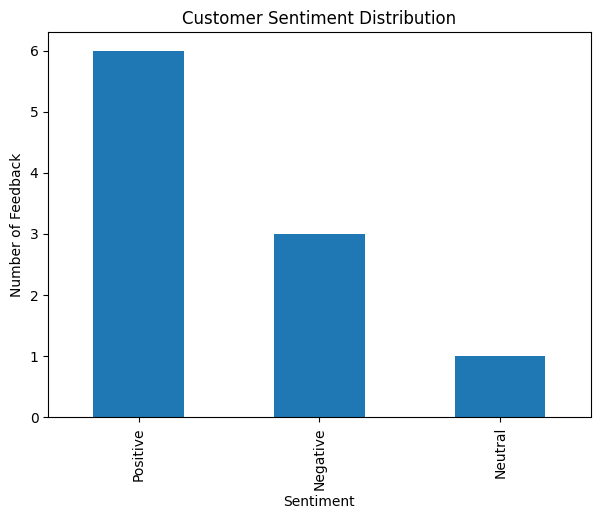

In [8]:
import matplotlib.pyplot as plt

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind="bar")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback")

plt.show()

In [9]:
import pandas as pd

# Load sentiment analysis data
df = pd.read_csv("sentiment_analysis.csv")


# Keywords for different product areas
improvement_keywords = {

    "Quality": [
        "quality",
        "working",
        "broken",
        "damage",
        "damaged",
        "stopped"
    ],

    "Pricing": [
        "price",
        "expensive",
        "cost",
        "pricing"
    ],

    "Packaging": [
        "packaging",
        "package",
        "box",
        "wrapped"
    ],

    "Usability": [
        "easy",
        "difficult",
        "confusing",
        "instructions",
        "use",
        "design"
    ],

    "Delivery": [
        "delivery",
        "shipping",
        "arrived",
        "slow"
    ]
}


def identify_area(text):

    text = text.lower()

    areas = []

    for area, keywords in improvement_keywords.items():

        for keyword in keywords:

            if keyword in text:
                areas.append(area)
                break

    if len(areas) == 0:
        return "Other"

    return ", ".join(areas)


# Identify areas
df["Improvement_Area"] = df["Feedback"].apply(
    identify_area
)

# Display results
print(
    df[
        [
            "Feedback",
            "Sentiment",
            "Improvement_Area"
        ]
    ]
)

# Save results
df.to_csv("improvement_analysis.csv", index=False)

                                            Feedback Sentiment  \
0  The product quality is excellent and I really ...  Positive   
1  The price is too high compared to similar prod...   Neutral   
2  The packaging was damaged when I received the ...  Negative   
3      Very easy to use and the design is beautiful.  Positive   
4        The product stopped working after one week.  Negative   
5  Good product but the packaging needs improvement.  Positive   
6  I am happy with the quality and reasonable price.  Positive   
7  The instructions are confusing and difficult t...  Negative   
8     Excellent product, but delivery was very slow.  Positive   
9  The product is expensive but the quality is good.  Positive   

     Improvement_Area  
0             Quality  
1             Pricing  
2  Quality, Packaging  
3           Usability  
4             Quality  
5           Packaging  
6    Quality, Pricing  
7           Usability  
8            Delivery  
9    Quality, Pricing  


In [10]:
from collections import Counter

area_counter = Counter()

for areas in df["Improvement_Area"]:

    for area in areas.split(", "):
        area_counter[area] += 1


print("\nImprovement Areas:")

for area, count in area_counter.most_common():

    print(area, ":", count)


Improvement Areas:
Quality : 5
Pricing : 3
Packaging : 2
Usability : 2
Delivery : 1


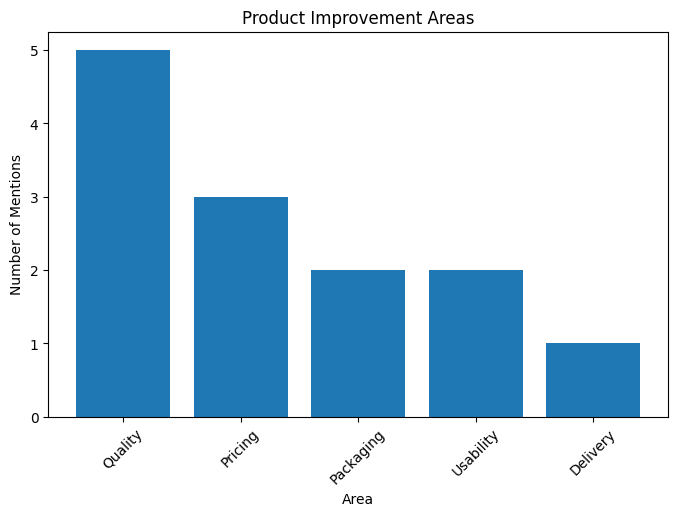

In [11]:
import matplotlib.pyplot as plt

areas = list(area_counter.keys())
counts = list(area_counter.values())

plt.figure(figsize=(8, 5))

plt.bar(areas, counts)

plt.title("Product Improvement Areas")

plt.xlabel("Area")

plt.ylabel("Number of Mentions")

plt.xticks(rotation=45)

plt.show()

In [12]:
import pandas as pd

# Load final analysis
df = pd.read_csv("improvement_analysis.csv")

# Total feedback
total_feedback = len(df)

# Count sentiments
positive = len(df[df["Sentiment"] == "Positive"])
negative = len(df[df["Sentiment"] == "Negative"])
neutral = len(df[df["Sentiment"] == "Neutral"])


# Calculate percentages
positive_percentage = (positive / total_feedback) * 100
negative_percentage = (negative / total_feedback) * 100
neutral_percentage = (neutral / total_feedback) * 100


print("BUSINESS INSIGHTS")

print("\nTotal Feedback:", total_feedback)

print(
    "Positive Feedback:",
    positive,
    f"({positive_percentage:.2f}%)"
)

print(
    "Negative Feedback:",
    negative,
    f"({negative_percentage:.2f}%)"
)

print(
    "Neutral Feedback:",
    neutral,
    f"({neutral_percentage:.2f}%)"
)


# Most common improvement areas
print("\nIMPROVEMENT AREAS")

area_counts = {}

for areas in df["Improvement_Area"]:

    for area in areas.split(", "):

        if area not in area_counts:
            area_counts[area] = 0

        area_counts[area] += 1


for area, count in sorted(
    area_counts.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(area, ":", count)


# Business recommendations
print("\nRECOMMENDATIONS")

if negative_percentage > 30:

    print(
        "High negative feedback detected. "
        "Management should investigate customer complaints."
    )

else:

    print(
        "Overall customer sentiment is relatively positive."
    )


if "Quality" in area_counts:

    print(
        "- Improve product quality and durability."
    )


if "Pricing" in area_counts:

    print(
        "- Review product pricing against competitors."
    )


if "Packaging" in area_counts:

    print(
        "- Improve packaging quality and protection."
    )


if "Usability" in area_counts:

    print(
        "- Improve product instructions and usability."
    )


if "Delivery" in area_counts:

    print(
        "- Improve delivery speed and logistics."
    )

BUSINESS INSIGHTS

Total Feedback: 10
Positive Feedback: 6 (60.00%)
Negative Feedback: 3 (30.00%)
Neutral Feedback: 1 (10.00%)

IMPROVEMENT AREAS
Quality : 5
Pricing : 3
Packaging : 2
Usability : 2
Delivery : 1

RECOMMENDATIONS
Overall customer sentiment is relatively positive.
- Improve product quality and durability.
- Review product pricing against competitors.
- Improve packaging quality and protection.
- Improve product instructions and usability.
- Improve delivery speed and logistics.


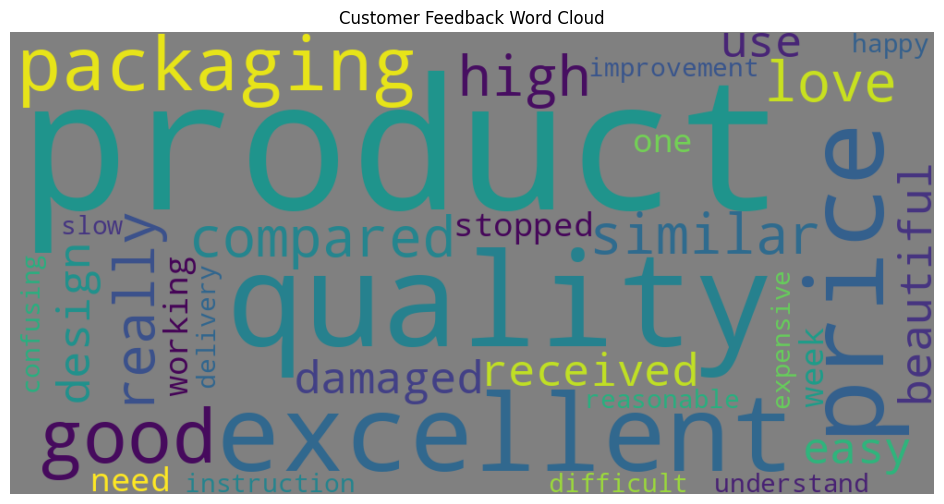

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud

# Load preprocessed data
df = pd.read_csv("preprocessed_feedback.csv")

# Combine all cleaned feedback
text = " ".join(
    df["Cleaned_Feedback"].astype(str)
)

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="grey"
).generate(text)


# Display word cloud
plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Customer Feedback Word Cloud")

plt.show()